# Marketing Campaign Analysis – Applied Data Science with Python

## Project Overview

Presents a complete Exploratory Data Analysis (EDA), data preprocessing workflow, hypothesis testing, and visualization dashboard for the Marketing Campaign dataset.

The objective is to analyze customer behavior and identify the major factors influencing customer acquisition and purchasing decisions.

---

# Business Objectives

The analysis focuses on:
- Customer demographics
- Purchase behavior
- Marketing campaign performance
- Shopping channel preferences
- Customer complaints and engagement

---

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Scikit-learn

---

# Instructions Before Running

1. Place the dataset file in the same directory as this notebook.
2. Ensure the dataset filename matches the one used in the notebook.
3. Install dependencies if required:

```bash
pip install pandas numpy matplotlib seaborn scipy scikit-learn
```


In [7]:
# ======================================
# Import Required Libraries
# ======================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Display settings
pd.set_option('display.max_columns', None)

# Visualization style
sns.set(style='whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Load Dataset

In this section:
- Load the dataset
- Inspect the dataset structure
- Validate important columns


In [8]:

# ======================================
# Load Dataset
# ======================================

file_path = "marketing_campaign.csv"

# Load dataset
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Clean Income column
df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

print("Dataset loaded successfully.")
print("\nDataset Shape:", df.shape)

# Display first rows
df.head()


Dataset loaded successfully.

Dataset Shape: (2240, 28)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [9]:
# ======================================
# Dataset Overview
# ======================================

print("Dataset Shape:", df.shape)

print("\nDataset Information:\n")
df.info()

print("\nSummary Statistics:\n")
df.describe(include='all')

Dataset Shape: (2240, 28)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   in

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,8/31/12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1095
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375,NaN
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391,NaN
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


# 2. Validate Important Variables

We verify:
- `Dt_Customer`
- `Income`

to ensure proper import and datatype handling.


In [10]:
# ======================================
# Validate Date and Income Columns
# ======================================

# Convert customer date column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Check datatypes
print(df[['Dt_Customer', 'Income']].dtypes)

# Display sample values
df[['Dt_Customer', 'Income']].head()

Dt_Customer    datetime64[ns]
Income                float64
dtype: object


C:\Users\anush\AppData\Local\Temp\ipykernel_35396\847817636.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])


,Dt_Customer,Income
0,2014-06-16,84835.0
1,2014-06-15,57091.0
2,2014-05-13,67267.0
3,2014-05-11,32474.0
4,2014-04-08,21474.0


# 3. Data Cleaning and Missing Value Imputation

The dataset contains missing income values.

We clean:
- Education categories
- Marital Status categories

Then perform income imputation using grouped median income.


In [11]:
# ======================================
# Check Missing Values
# ======================================

print(df.isna().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64


In [6]:
# ======================================
# Clean Education Categories
# ======================================

print("Unique Education Categories Before Cleaning:\n")
print(df['Education'].unique())

# Example standardization
df['Education'] = df['Education'].replace({
    '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'PhD': 'Doctorate',
    'Master': 'Postgraduate'
})

print("\nUnique Education Categories After Cleaning:\n")
print(df['Education'].unique())

Unique Education Categories Before Cleaning:

['Graduation' 'PhD' '2n Cycle' 'Master' 'Basic']

Unique Education Categories After Cleaning:

['Graduate' 'Doctorate' 'Undergraduate' 'Postgraduate' 'Basic']


In [12]:
# ======================================
# Clean Marital Status Categories
# ======================================

print("Unique Marital Status Before Cleaning:\n")
print(df['Marital_Status'].unique())

# Consolidate categories
df['Marital_Status'] = df['Marital_Status'].replace({
    'Together': 'Relationship',
    'Married': 'Relationship',
    'Divorced': 'Single',
    'Widow': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
})

print("\nUnique Marital Status After Cleaning:\n")
print(df['Marital_Status'].unique())

Unique Marital Status Before Cleaning:

['Divorced' 'Single' 'Married' 'Together' 'Widow' 'YOLO' 'Alone' 'Absurd']

Unique Marital Status After Cleaning:

['Single' 'Relationship' 'Alone']


In [13]:
# ======================================
# Income Imputation
# ======================================

# Fill missing income using median grouped by
# Education and Marital Status

df['Income'] = df.groupby(
    ['Education', 'Marital_Status']
)['Income'].transform(
    lambda x: x.fillna(x.median())
)

print("Missing Income Values:\n")
print(df['Income'].isna().sum())

Missing Income Values:

0


# 4. Feature Engineering

We create:
- Total children
- Customer age
- Total spending
- Total purchases


In [14]:
# ======================================
# Create Total Children Variable
# ======================================

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

df[['Kidhome', 'Teenhome', 'Total_Children']].head()

,Kidhome,Teenhome,Total_Children
0,0,0,0
1,0,0,0
2,0,1,1
3,1,1,2
4,1,0,1


In [15]:
# ======================================
# Create Age Variable
# ======================================

current_year = pd.Timestamp.now().year

df['Age'] = current_year - df['Year_Birth']

df[['Year_Birth', 'Age']].head()

,Year_Birth,Age
0,1970,56
1,1961,65
2,1958,68
3,1967,59
4,1989,37


In [16]:
# ======================================
# Create Total Spending Variable
# ======================================

spending_columns = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df['Total_Spending'] = df[spending_columns].sum(axis=1)

df[['Total_Spending']].head()

,Total_Spending
0,1190
1,577
2,251
3,11
4,91


In [32]:
# ======================================
# Create Total Purchases Variable
# ======================================

purchase_columns = [
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df['Total_Purchases'] = df[purchase_columns].sum(axis=1)

df[['Total_Purchases']].head()

,Total_Purchases
0,15
1,18
2,11
3,4
4,8


# 5. Outlier Detection and Treatment

We use:
- Boxplots
- Histograms

to identify outliers and understand data distributions.


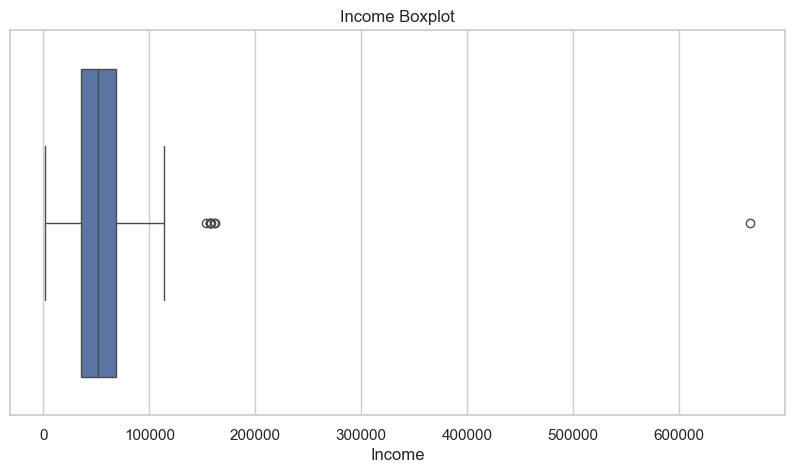

In [17]:
# ======================================
# Boxplot for Income
# ======================================

plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Income'])

plt.title("Income Boxplot")

plt.show()

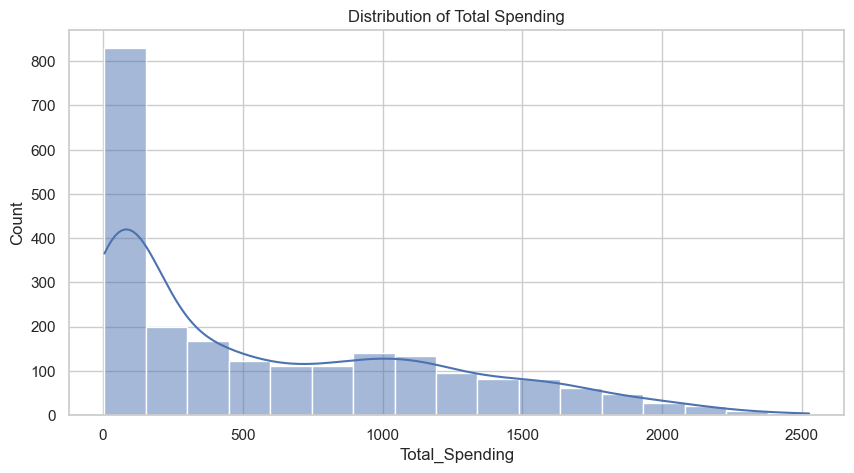

In [18]:
# ======================================
# Histogram for Total Spending
# ======================================

plt.figure(figsize=(10, 5))

sns.histplot(df['Total_Spending'], kde=True)

plt.title("Distribution of Total Spending")

plt.show()

In [19]:
# ======================================
# Outlier Treatment Using IQR Method
# ======================================

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['Income'] >= lower_bound) &
    (df['Income'] <= upper_bound)
]

print("Dataset shape after outlier removal:", df.shape)

Dataset shape after outlier removal: (2232, 31)


# 6. Encoding Categorical Variables

We apply:
- Ordinal Encoding
- One-Hot Encoding

based on variable characteristics.


In [20]:
# ======================================
# Ordinal Encoding for Education
# ======================================

education_order = {
    'Basic': 1,
    'Undergraduate': 2,
    'Graduate': 3,
    'Postgraduate': 4,
    'Doctorate': 5
}

df['Education_Encoded'] = df['Education'].map(education_order)

df[['Education', 'Education_Encoded']].head()

,Education,Education_Encoded
0,Graduation,NaN
1,Graduation,NaN
2,Graduation,NaN
3,Graduation,NaN
4,Graduation,NaN


In [21]:
# ======================================
# One-Hot Encoding for Marital Status
# ======================================

df = pd.get_dummies(
    df,
    columns=['Marital_Status'],
    drop_first=True
)

df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Children,Age,Total_Spending,Education_Encoded,Marital_Status_Relationship,Marital_Status_Single
0,1826,1970,Graduation,84835.0,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP,0,56,1190,NaN,False,True
1,1,1961,Graduation,57091.0,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA,0,65,577,NaN,False,True
2,10476,1958,Graduation,67267.0,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US,1,68,251,NaN,True,False
3,1386,1967,Graduation,32474.0,1,1,2014-05-11,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS,2,59,11,NaN,True,False
4,5371,1989,Graduation,21474.0,1,0,2014-04-08,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP,1,37,91,NaN,False,True


# 7. Correlation Heatmap

A heatmap helps identify:
- Strong correlations
- Feature relationships
- Multicollinearity


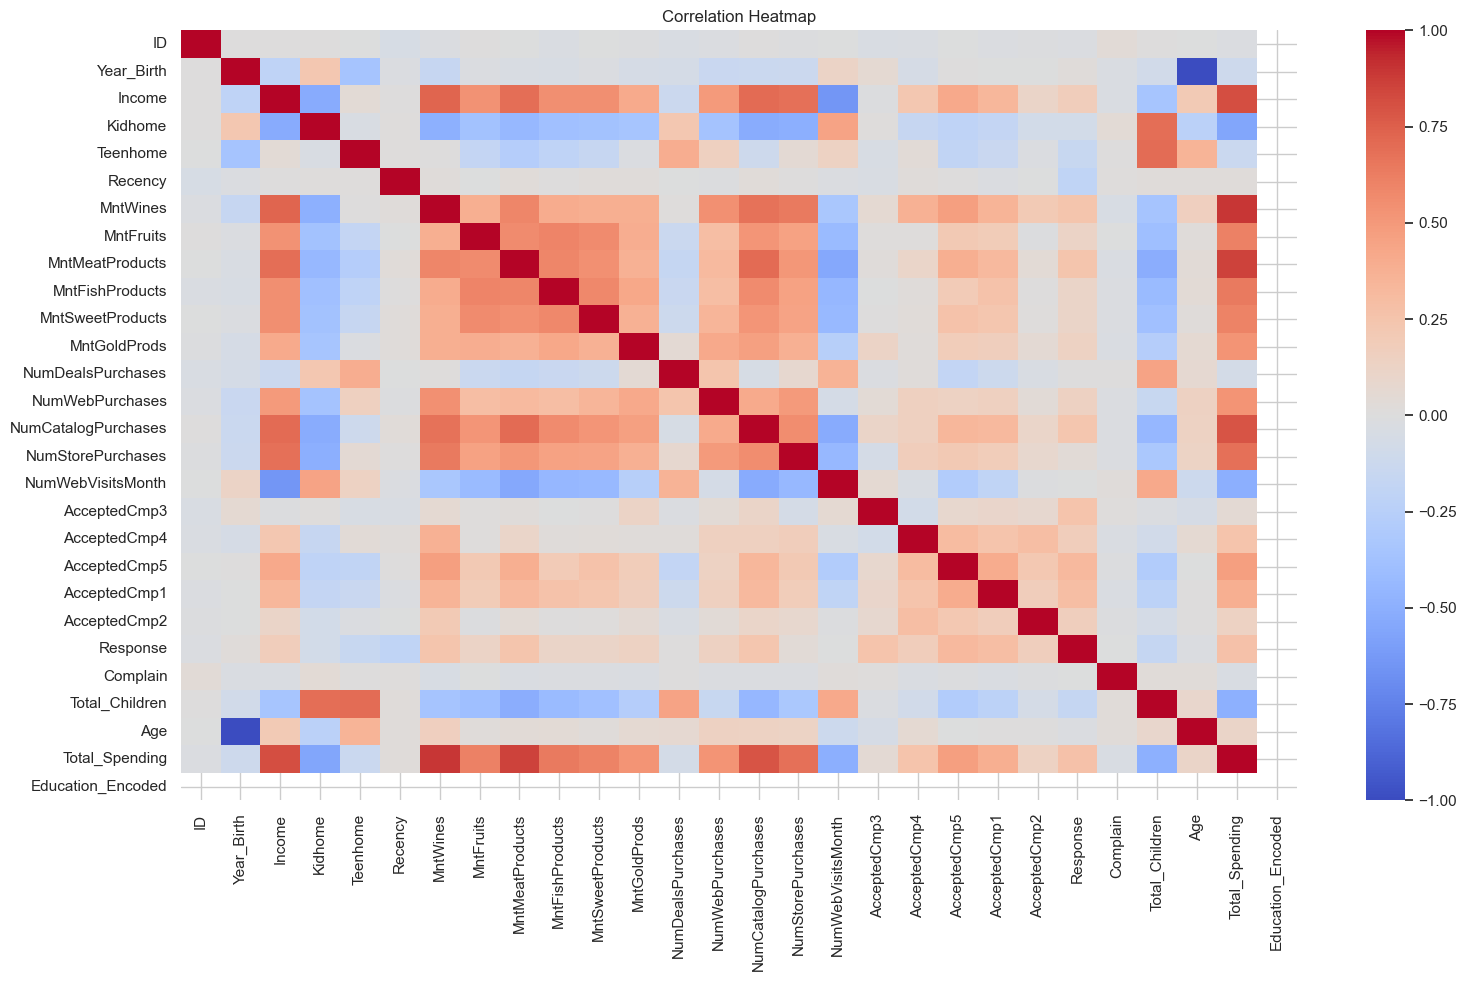

In [22]:
# ======================================
# Correlation Heatmap
# ======================================

plt.figure(figsize=(18, 10))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

# 8. Hypothesis Testing

We test the following hypotheses:
1. Older customers prefer in-store shopping.
2. Customers with children prefer online shopping.
3. Physical store sales may be cannibalized by alternative channels.
4. The United States outperforms other countries in purchases.


In [23]:
# ======================================
# Hypothesis 1
# Older customers prefer store purchases
# ======================================

correlation_age_store = df['Age'].corr(df['NumStorePurchases'])

print("Correlation between Age and Store Purchases:")
print(correlation_age_store)

Correlation between Age and Store Purchases:
0.12757699136193562


In [24]:
# ======================================
# Hypothesis 2
# Customers with children prefer online shopping
# ======================================

correlation_children_web = df['Total_Children'].corr(df['NumWebPurchases'])

print("Correlation between Children and Web Purchases:")
print(correlation_children_web)

Correlation between Children and Web Purchases:
-0.1494439363485706


In [25]:
# ======================================
# Hypothesis 3
# Store sales cannibalization analysis
# ======================================

store_web_corr = df['NumStorePurchases'].corr(df['NumWebPurchases'])

print("Correlation between Store and Web Purchases:")
print(store_web_corr)

Correlation between Store and Web Purchases:
0.49902984993624805


In [33]:
# ======================================
# Hypothesis 4
# US vs Rest of World Purchase Comparison
# ======================================

# Check if Country column exists

if 'Country' in df.columns:

    usa_sales = df[df['Country'] == 'US']['Total_Purchases']
    rest_sales = df[df['Country'] != 'US']['Total_Purchases']

    t_stat, p_value = ttest_ind(
        usa_sales,
        rest_sales,
        equal_var=False
    )

    print("T-Statistic:", t_stat)
    print("P-Value:", p_value)

else:
    print("Country column not available in dataset.")

T-Statistic: 1.4290967747007153
P-Value: 0.15562360379395063


# 9. Visualization-Based Business Analysis


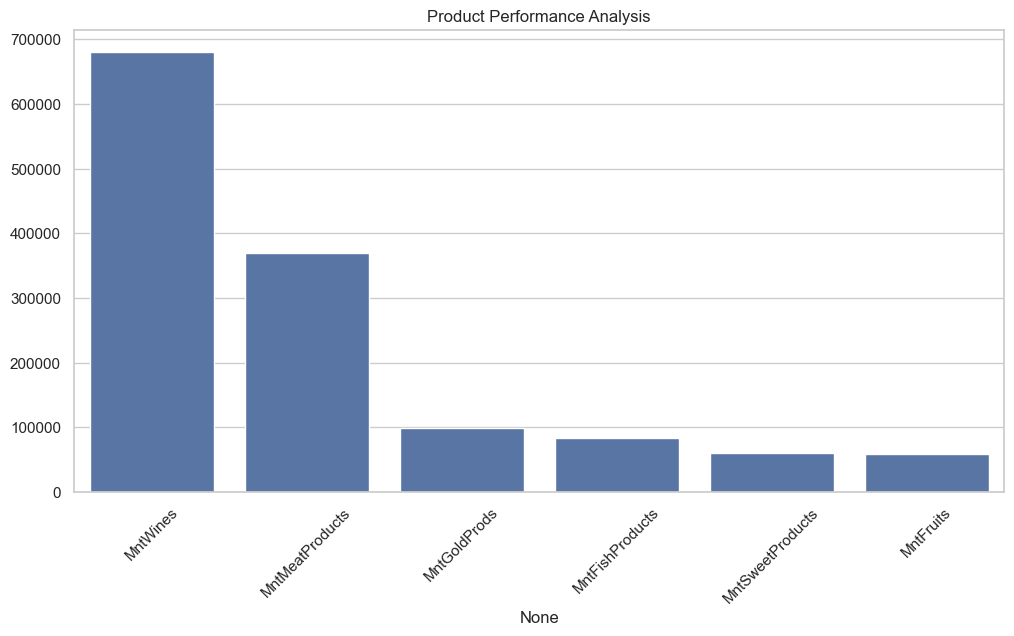

In [27]:
# ======================================
# Top Performing Products
# ======================================

product_sales = df[spending_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)

plt.xticks(rotation=45)

plt.title("Product Performance Analysis")

plt.show()

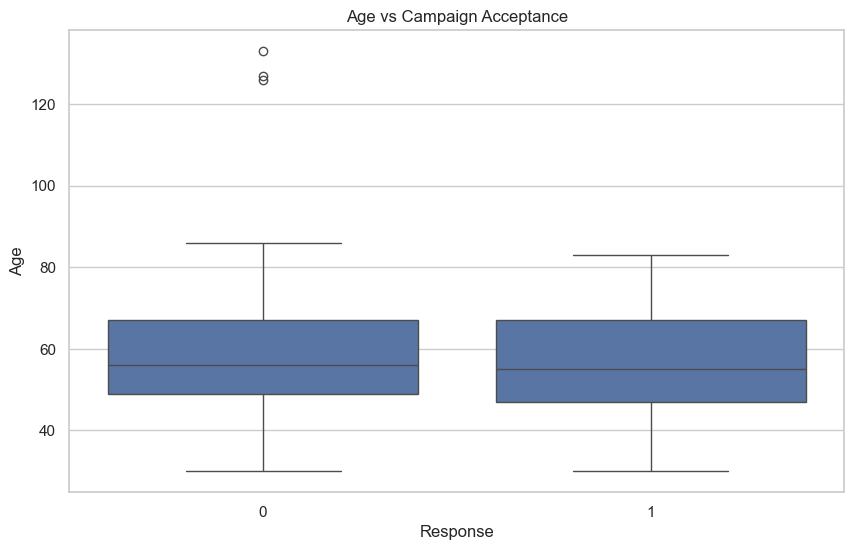

In [28]:
# ======================================
# Age vs Last Campaign Acceptance
# ======================================

if 'Response' in df.columns:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        x='Response',
        y='Age',
        data=df
    )

    plt.title("Age vs Campaign Acceptance")

    plt.show()

else:
    print("Response column not found.")

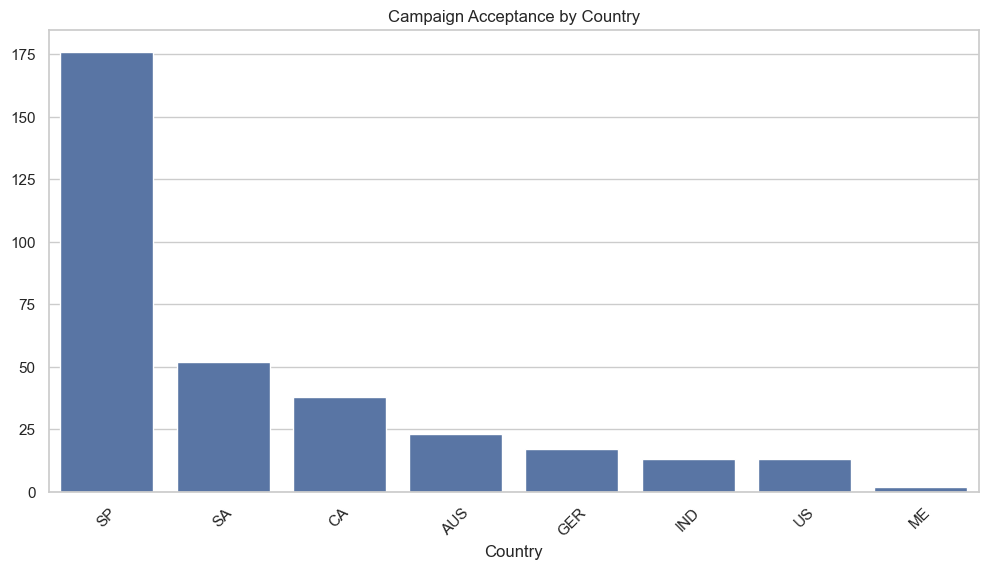

In [29]:
# ======================================
# Country with Highest Campaign Acceptance
# ======================================

if 'Country' in df.columns and 'Response' in df.columns:

    accepted = df[df['Response'] == 1]

    country_acceptance = accepted['Country'].value_counts()

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=country_acceptance.index,
        y=country_acceptance.values
    )

    plt.title("Campaign Acceptance by Country")

    plt.xticks(rotation=45)

    plt.show()

else:
    print("Required columns not found.")

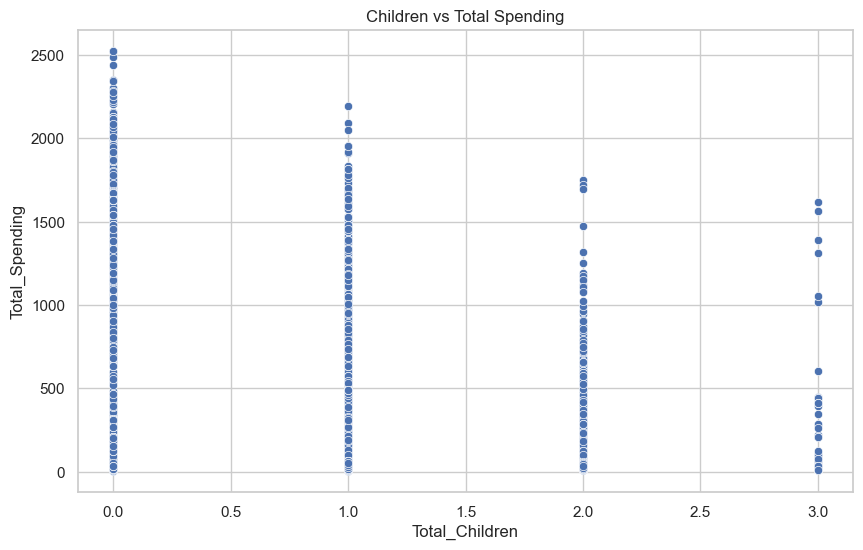

In [30]:
# ======================================
# Children vs Total Spending
# ======================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Total_Children',
    y='Total_Spending',
    data=df
)

plt.title("Children vs Total Spending")

plt.show()

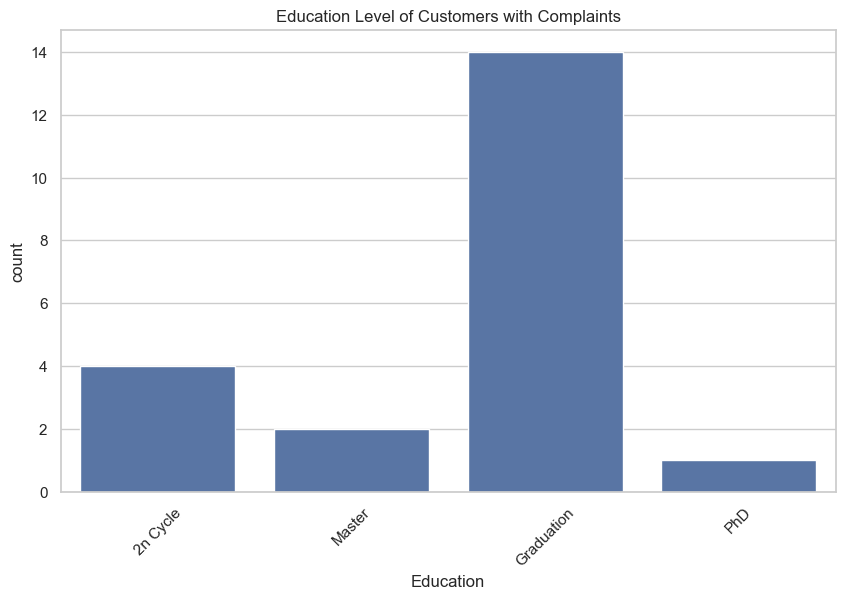

In [31]:
# ======================================
# Education Level of Customers with Complaints
# ======================================

if 'Complain' in df.columns:

    complain_df = df[df['Complain'] == 1]

    plt.figure(figsize=(10, 6))

    sns.countplot(
        x='Education',
        data=complain_df
    )

    plt.title("Education Level of Customers with Complaints")

    plt.xticks(rotation=45)

    plt.show()

else:
    print("Complain column not found.")

# 10. Key Business Insights

## Observations
- High-spending products can guide inventory planning.
- Online purchasing behavior varies across demographics.
- Campaign acceptance may differ based on age and geography.
- Customers with children may prefer convenient digital channels.

---

# Recommendations

## Marketing Recommendations
- Target younger customers using digital campaigns.
- Use personalized offers for families.
- Improve omnichannel strategies.
- Optimize underperforming products.

## Data Recommendations
- Continue customer segmentation.
- Monitor complaint trends.
- Enhance campaign personalization.

---

# Why Seaborn?

Seaborn is recommended because:
- It simplifies statistical visualization.
- Provides attractive visual themes.
- Integrates seamlessly with Pandas.
- Excellent for exploratory data analysis.


# 11. Conclusion

This notebook successfully demonstrates:
- Data cleaning
- Missing value imputation
- Feature engineering
- Outlier treatment
- Encoding techniques
- Correlation analysis
- Hypothesis testing
- Business-oriented visualizations

The analysis provides actionable insights that can help improve marketing effectiveness and customer acquisition strategies.
